In [3]:
%pip install xgboost catboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 1.7 MB/s eta 0:01:01
   ---------------------------------------- 0.8/101.7 MB 1.8 MB/s eta 0:00:58
    --------------------------------------- 1.3/101.7 MB 1.7 MB/s eta 0:00:59
    --------------------------------------- 1.6/101.7 MB 1.6 MB/s eta 0:01:01
    --------------------------------------- 1.8/101.7 MB 1.6 MB/s eta 0:01:03
    --------------------------------------- 2.1/101.7 MB 1.4 MB/s eta 0:01:10
    --------------------------------------- 2.4/101.7 MB 1.4 MB/s eta 0:01:12
   - -------------------------------------- 2.6/101.7 MB 1.4 MB/s eta 0:01:12
   - -------------------------------------- 2.6/101.7 MB 1.4 MB/s eta 0:01:12
   - -------------------------------------- 2.9/101.7 MB 1.3 MB/s eta 0:01:14
   - --

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Metrics
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Models
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor

# Model selection
from sklearn.model_selection import train_test_split, GridSearchCV

# Boosting models
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

# Warnings
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import RandomizedSearchCV



In [3]:
df = pd.read_csv('data/stud.csv')
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
x = df.drop(columns =['math_score'],axis = 1)

In [10]:
y = df['math_score']

In [7]:
num_features = x.select_dtypes(exclude='object').columns
cat_features = x.select_dtypes(include='object').columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
[
    ("OneHotEncoder", oh_transformer, cat_features),
    ("StandardScaler", numeric_transformer, num_features)
]

)

In [8]:
x = preprocessor.fit_transform(x)

In [11]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((800, 19), (200, 19), (800,), (200,))

In [16]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mse)
    r2 = r2_score(true, predicted)
    return mae, mse, rmse, r2

In [17]:
models  = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "DecisionTreeRegressor": DecisionTreeRegressor(),
    "RandomForestRegressor": RandomForestRegressor(),
    "AdaBoostRegressor": AdaBoostRegressor(),
    "GradientBoostingRegressor": GradientBoostingRegressor(),
    "XGBRegressor": XGBRegressor(),
    "CatBoostRegressor": CatBoostRegressor(verbose=0),
    "KNeighborsRegressor": KNeighborsRegressor()


}

model_list = []
r2_list = []

for name, model in models.items():
    model.fit(x_train, y_train)
    
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    train_mae, train_mse, train_rmse, train_r2 = evaluate_model(y_train, y_train_pred)
    test_mae, test_mse, test_rmse, test_r2 = evaluate_model(y_test, y_test_pred)

    model_list.append(name)
    r2_list.append(test_r2)

    print(f"Model: {name}")
    print("Training Performance:")
    print(f"MAE: {train_mae}")
    print(f"MSE: {train_mse}")
    print(f"RMSE: {train_rmse}")
    print(f"R2 Score: {train_r2}")
    print("-"*30)

Model: LinearRegression
Training Performance:
MAE: 4.266711846071957
MSE: 28.33487038064859
RMSE: 5.323050852720514
R2 Score: 0.8743172040139593
------------------------------
Model: Ridge
Training Performance:
MAE: 4.26498782372598
MSE: 28.337788233082442
RMSE: 5.323324922741654
R2 Score: 0.8743042615212909
------------------------------
Model: Lasso
Training Performance:
MAE: 5.206302661246526
MSE: 43.47840400585579
RMSE: 6.593815587795566
R2 Score: 0.8071462015863456
------------------------------
Model: DecisionTreeRegressor
Training Performance:
MAE: 0.01875
MSE: 0.078125
RMSE: 0.2795084971874737
R2 Score: 0.9996534669718089
------------------------------
Model: RandomForestRegressor
Training Performance:
MAE: 1.817708333333333
MSE: 5.274756896896259
RMSE: 2.296683891373878
R2 Score: 0.9766031682501948
------------------------------
Model: AdaBoostRegressor
Training Performance:
MAE: 4.729646670823562
MSE: 33.289932390246065
RMSE: 5.769742835711663
R2 Score: 0.8523384181827829
---

In [18]:
pd.DataFrame({"Model": model_list, "R2 Score": r2_list}).sort_values(by="R2 Score", ascending=False)

,Model,R2 Score
1,Ridge,0.880593
0,LinearRegression,0.880433
6,GradientBoostingRegressor,0.872183
5,AdaBoostRegressor,0.852892
8,CatBoostRegressor,0.851632
4,RandomForestRegressor,0.851286
7,XGBRegressor,0.827797
2,Lasso,0.825320
9,KNeighborsRegressor,0.783813
3,DecisionTreeRegressor,0.743423


In [19]:
lin_model = LinearRegression(fit_intercept=True)
lin_model.fit(x_train, y_train)
y_pred = lin_model.predict(x_test)
score = r2_score(y_test,y_pred)
print("Accuracy of Model is %.2f" % score)

Accuracy of Model is 0.88


Text(0, 0.5, 'Predicted Values')

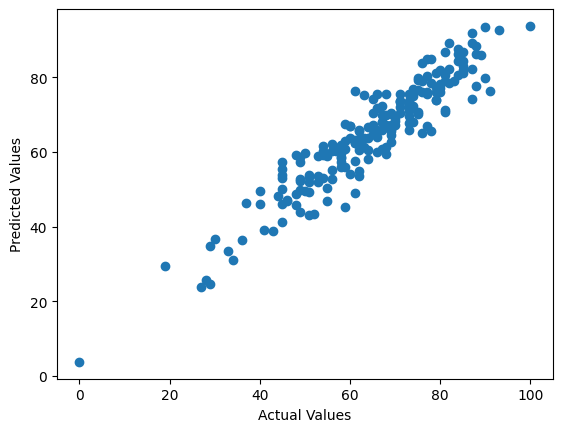

In [20]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

<Axes: xlabel='math_score'>

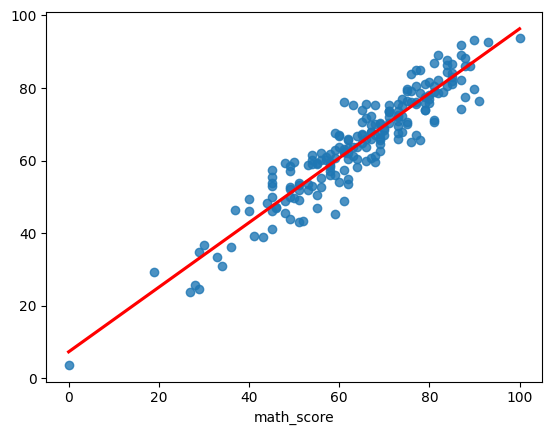

In [21]:
sns.regplot(x = y_test, y = y_pred, ci =None, line_kws={"color": "red"})

In [22]:
pred_df = pd.DataFrame({'Actual':y_test,'Predicted':y_pred,'Diffrence': y_test-y_pred})

In [23]:
pred_df

,Actual,Predicted,Diffrence
521,91,76.387970,14.612030
737,53,58.885970,-5.885970
740,80,76.990265,3.009735
660,74,76.851804,-2.851804
411,84,87.627378,-3.627378
...,...,...,...
408,52,43.409149,8.590851
332,62,62.152214,-0.152214
208,74,67.888395,6.111605
613,65,67.022287,-2.022287
